In [1]:
from plntxps import *
import pandas as pd
import re

data processed with plnt_xps version 0.1.1
our crew is replaceable, your package isn't!


In [2]:
RhAl2O3 = datafile("example data/2024-09-16 Rh on Al2O3 for Marlon 7-21-24 fit.xy")

In [3]:
RhAl2O3.list_spectra()

Index  Name                               Time (min)  Comment             
0      overall 8B                         882.12      workfunction stored as 4.5430 eV during the time of recording the spectra
..........................................................................
1      overall 8B, shifted work function  891.98      workfunction stored as 2.0 eV during acquisition
..........................................................................
2      Rh 3d 10 eV                        917.13      workfunction stored as 4.5430 eV during the time of recording the spectra
..........................................................................
3      overall 8B post-gold evaporation   1052.43     
..........................................................................
4      Rh 3d 10 eV                        1065.98     
..........................................................................
5      Au 4d 10 eV                        1091.77     
       Peak Fit
..........

In [4]:
df = pd.read_csv('../plntxps/xpsdb/HandbookXPS.csv', sep = ';')

In [5]:
df

,AtomicLevel.symbol,AtomicLevel.level,AtomicLevel.number,BindingEnergy,Reference
0,Li,1s,3,55.600000000000001 eV,NaN
1,Be,1s,4,111.8 eV,NaN
2,B,1s,5,189.40000000000001 eV,NaN
3,C,1s,6,284.5 eV,NaN
4,N,1s,7,398.10000000000002 eV,NaN
...,...,...,...,...,...
837,Bk,4f,97,504.89999999999998 eV,NaN
838,Bk,6p,97,23.300000000000001 eV,NaN
839,Cf,4d,98,957.39999999999998 eV,NaN
840,Cf,4f,98,530.70000000000005 eV,NaN


In [6]:
def get_positions_and_names(element):
    positions = (df[
        df['AtomicLevel.symbol'].apply(lambda x: x.lower()) == element.lower()]
        ['BindingEnergy']
        .apply(lambda x : float(re.sub(r'[^0-9.]', '', x)))
        .tolist())
    levels = (df[
        df['AtomicLevel.symbol'].apply(lambda x: x.lower()) == element.lower()]
        ['AtomicLevel.level']
        .apply(lambda x: f"{element} {x}")).tolist()
    return positions, levels

get_positions_and_names("Rh")

([629.0, 521.0, 497.0, 311.9, 307.2, 81.0, 48.0, 505.0, 309.1],
 ['Rh 3s',
  'Rh 3p1/2',
  'Rh 3p3/2',
  'Rh 3d3/2',
  'Rh 3d5/2',
  'Rh 4s',
  'Rh 4p',
  'Rh 3p',
  'Rh 3d'])

In [7]:
(df[
    df["AtomicLevel.symbol"] == "Rh"]
    ["BindingEnergy"]
    .apply(lambda be_string: float(re.sub(r'[^0-9.]', "", be_string)))
    .tolist()
)

[629.0, 521.0, 497.0, 311.9, 307.2, 81.0, 48.0, 505.0, 309.1]

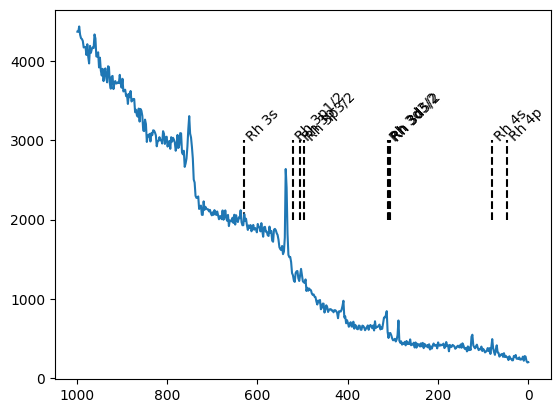

In [8]:
def plot_peaks(element, vline_min, vline_max, **kwargs):
    peaks = (df[
        df['AtomicLevel.symbol'].apply(lambda x: x.lower()) == element.lower()]
        ['BindingEnergy']
        .apply(lambda x : float(re.sub(r'[^0-9.]', '', x)))
        .tolist())
    plt.vlines(peaks, 2e3, 3e3, **kwargs)
    positions, names = get_positions_and_names(element)
    for position, name in zip(positions, names):
        plt.annotate(name, (position, vline_max), rotation = 45)

plot_peaks('Rh', 2e3, 3e3, color = 'black', ls = 'dashed')

RhAl2O3.spectra[1].plot()
plt.gca().invert_xaxis()